# Regression

## Imports

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import time
from sklearn.metrics import mean_squared_error
from dataset import CaliforniaHousingDataset as Dataset
from pipeline import get_pipeline
from eda.eda import EDA
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
plt.rcParams['figure.figsize'] = (12, 8)

# Linear regression
from linear_regression.diagnostics import GaussMarkovDiagnostics
from linear_regression.ols import OLS
from linear_regression.wls import WLS

# Nonlinear basis
from nonlinear_basis.polynomial import PolynomialBasis
from nonlinear_basis.fourier import FourierBasis
from nonlinear_basis.rbf import RBF

# Advanced
from advanced.gpr import GPR
from advanced.irls import IRLS
from advanced.bayes_reg import BayesianLinearRegression
from advanced.bayesian_em_vs_cv import compare_em_vs_cv

# Evaluation
from evaluation.visualizer import Visualizer
from evaluation.evaluator import Evaluator
from evaluation.validation_curve import run_validation_curve

## Dataset

### Missing values

In [2]:
    d = Dataset()
    eda = EDA(d)

    print(eda.missing_values())


    # eda.plot_target_distribution()
    # eda.plot_scatter_features_target()
    # eda.plot_corrrelation_matrix()
    # eda.plot_outliers()
    # plt.show()

                 feature  missing_count  missing_percent
MedInc            MedInc              0              0.0
HouseAge        HouseAge              0              0.0
AveRooms        AveRooms              0              0.0
AveBedrms      AveBedrms              0              0.0
Population    Population              0              0.0
AveOccup        AveOccup              0              0.0
Latitude        Latitude              0              0.0
Longitude      Longitude              0              0.0
MedHouseVal  MedHouseVal              0              0.0


### Descriptive statistics

In [3]:
print(eda.descriptive_stats())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

### Target distribution

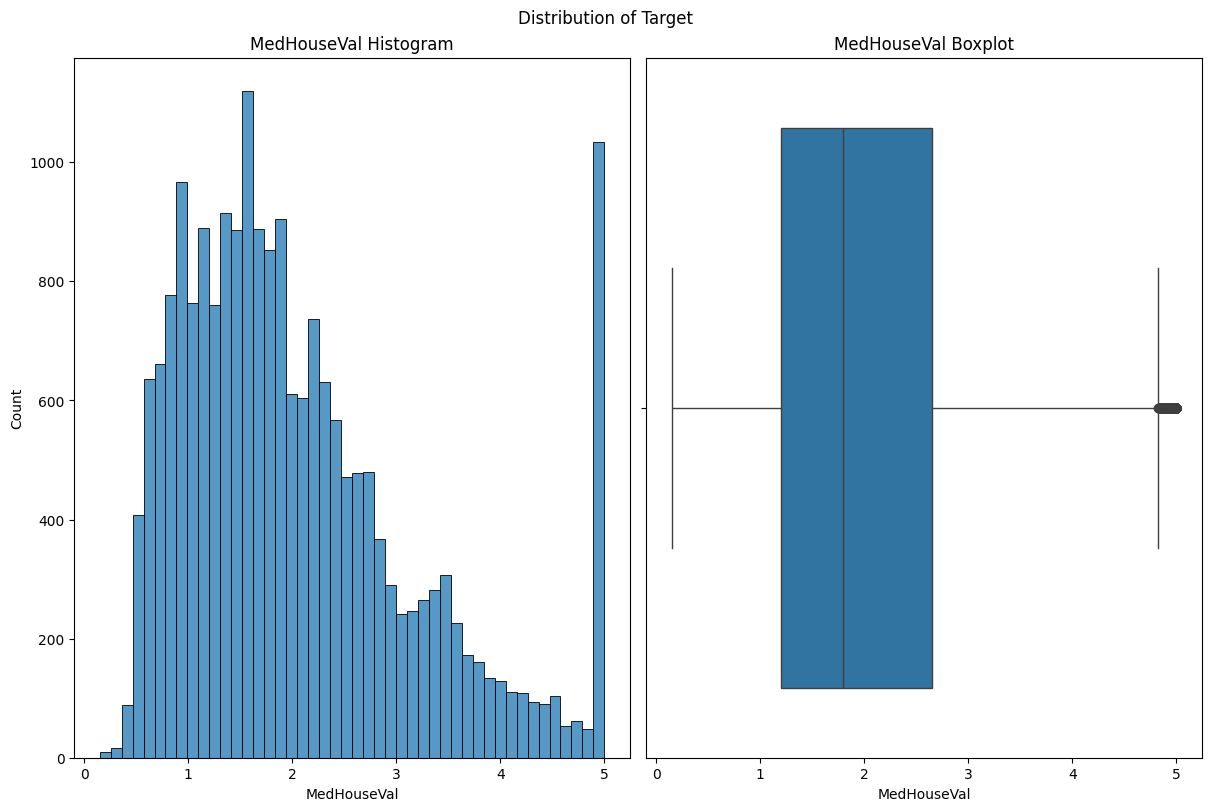

In [4]:
eda.plot_target_distribution()
plt.show()

### Scatter

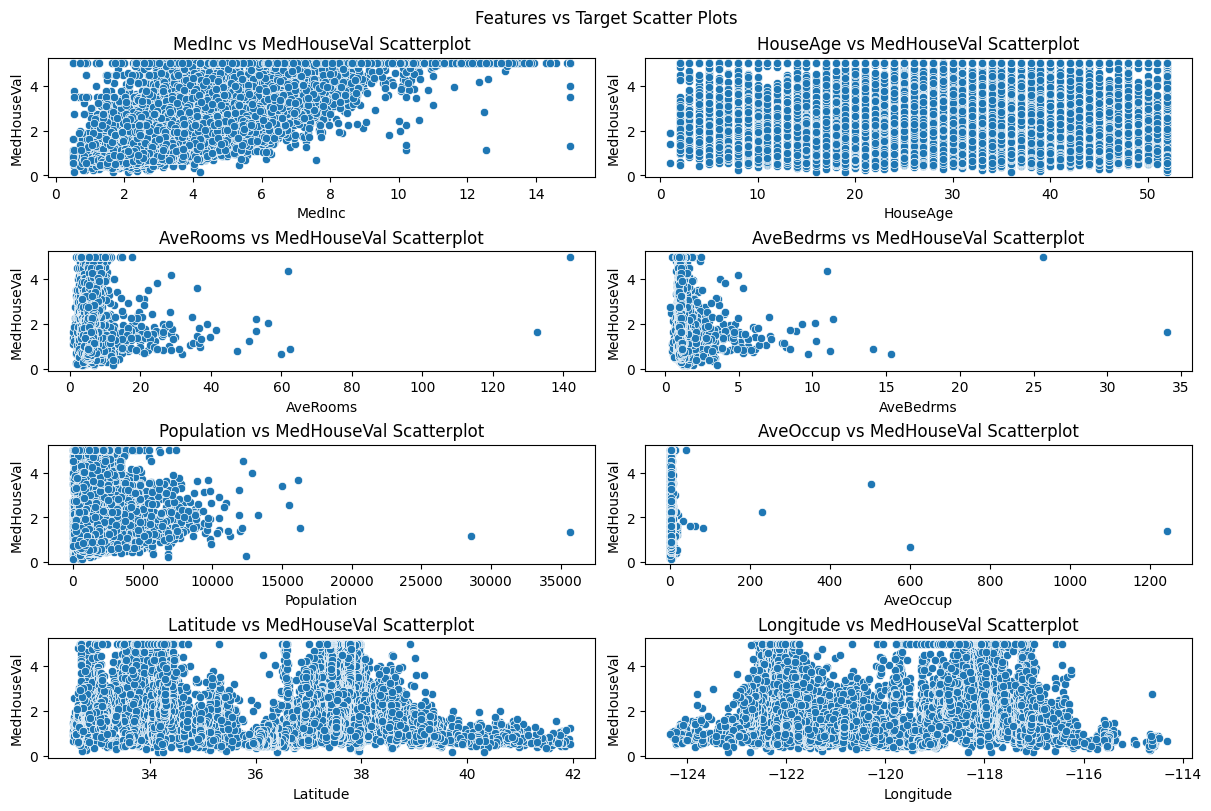

In [5]:
eda.plot_scatter_features_target()
plt.show()

### Correlation matrix

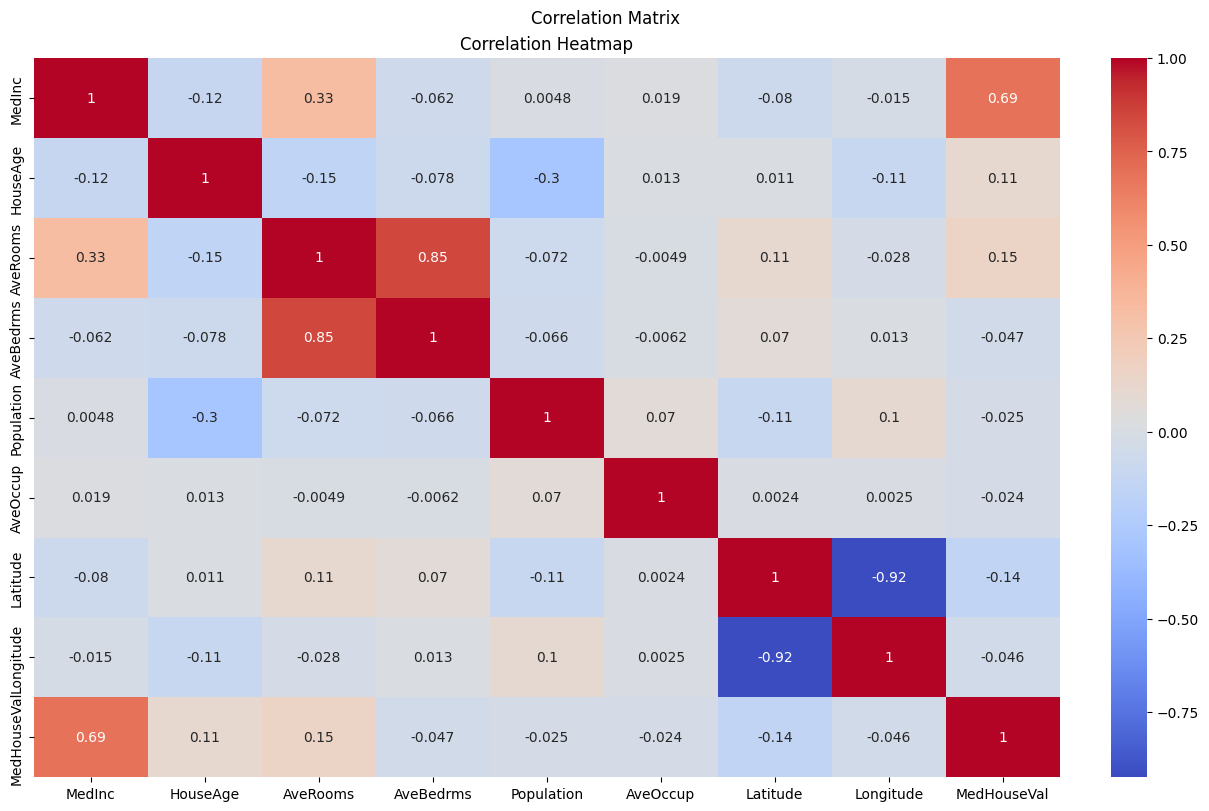

In [6]:
eda.plot_corrrelation_matrix()
plt.show()

### Outliers

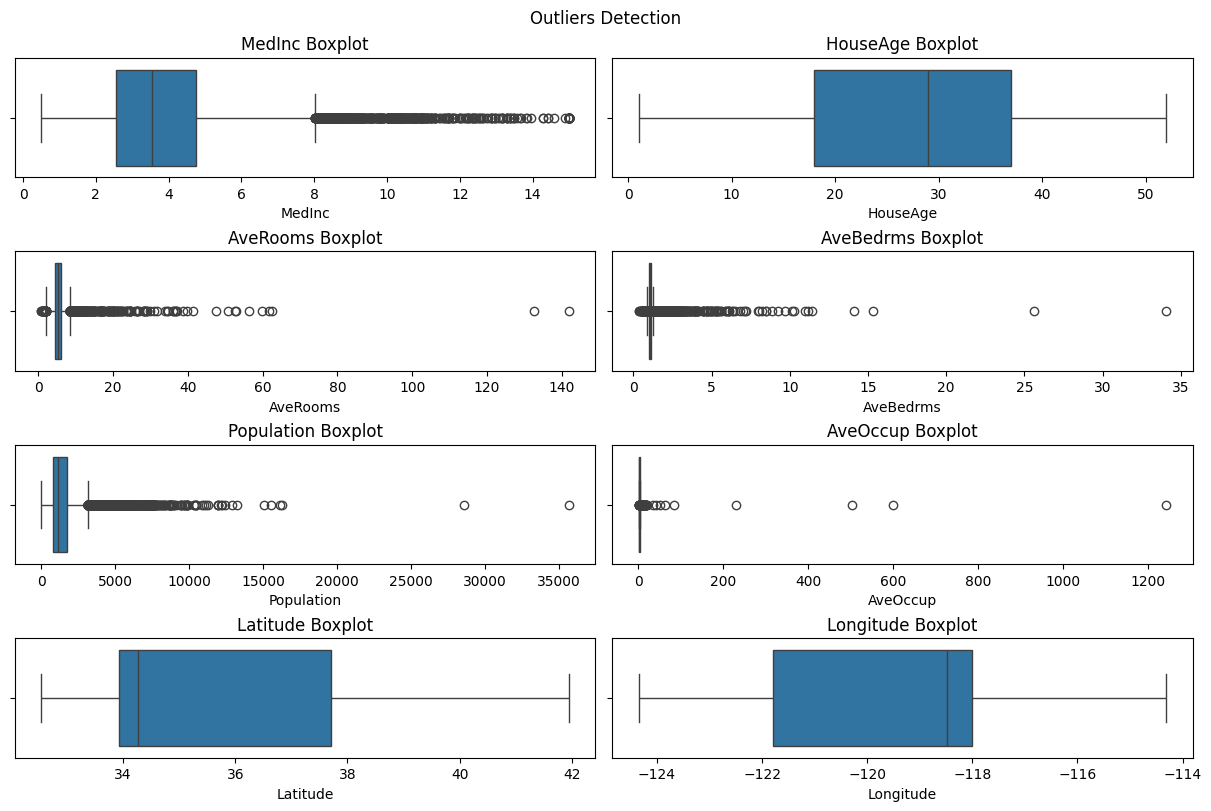

In [7]:
eda.plot_outliers()
plt.show()

### Preprocessing

In [8]:
d.split()

## Models

### Linear regression

#### Gauss-Markov hypothesis

In [9]:
model = get_pipeline(OLS())
model.fit(d.X_train, d.y_train)
y_pred_train = model.predict(d.X_train)
diag = GaussMarkovDiagnostics()

##### Residuals plot

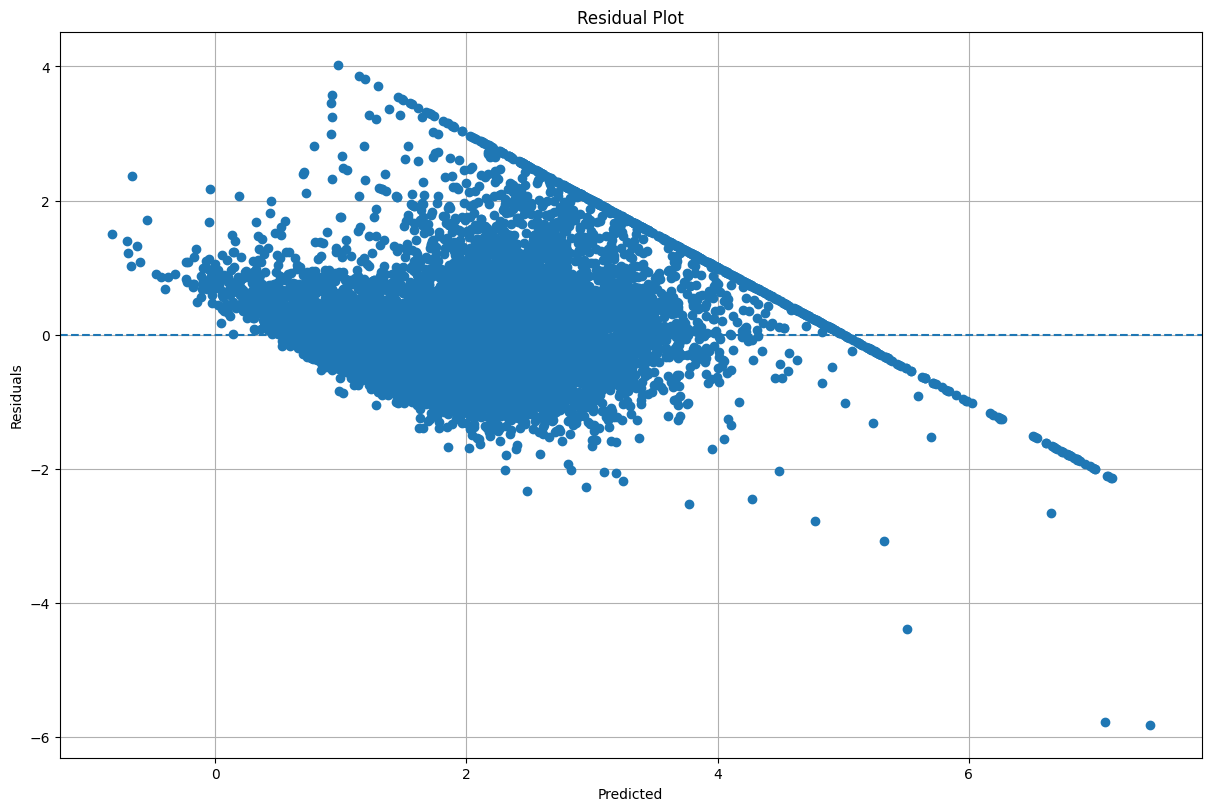

In [10]:
residuals_train = d.y_train - y_pred_train
diag.plot_residuals(d.y_train, y_pred_train)

plt.show()

##### QQ-plot

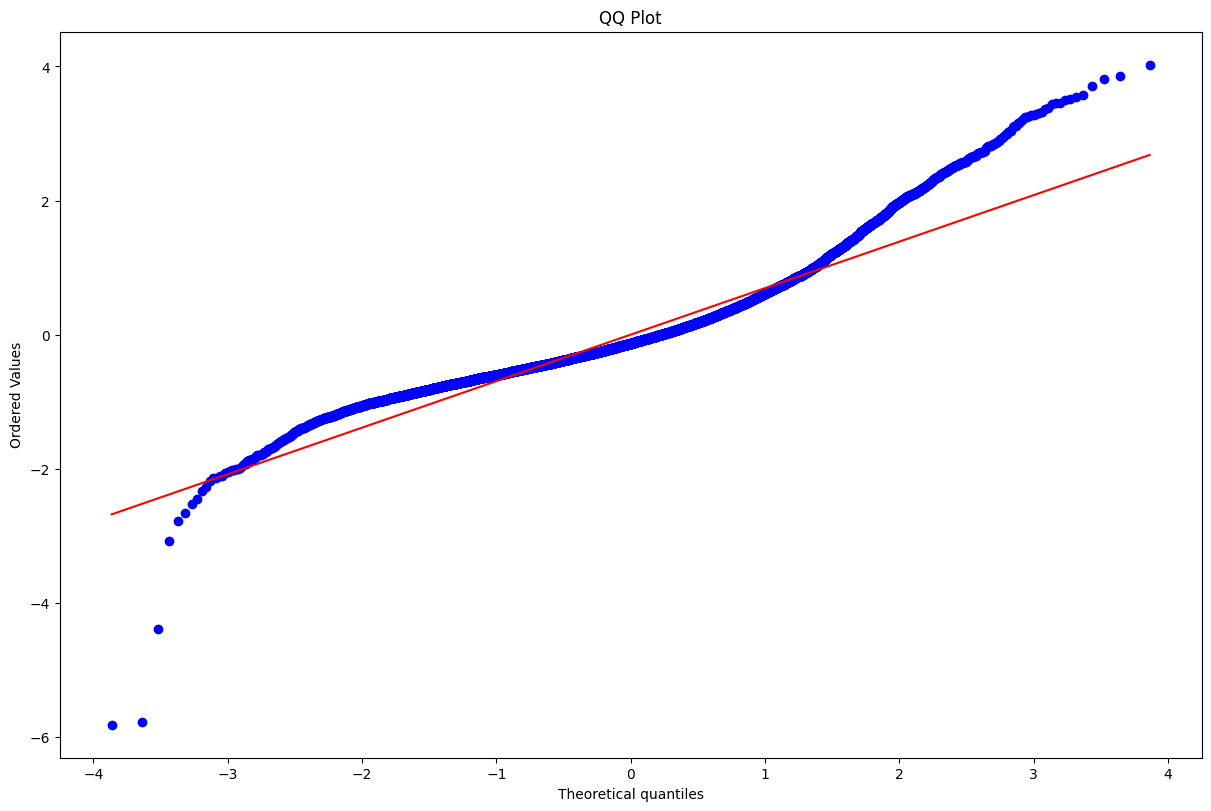

In [11]:
diag.plot_qq(residuals_train)
plt.show()

##### Breusch–Pagan test

{'LM Stat': np.float64(1248.6155930281107), 'LM p-value': np.float64(2.9971092971919424e-264), 'F Stat': np.float64(173.4517799184437), 'F p-value': np.float64(1.0491135950864607e-278)}


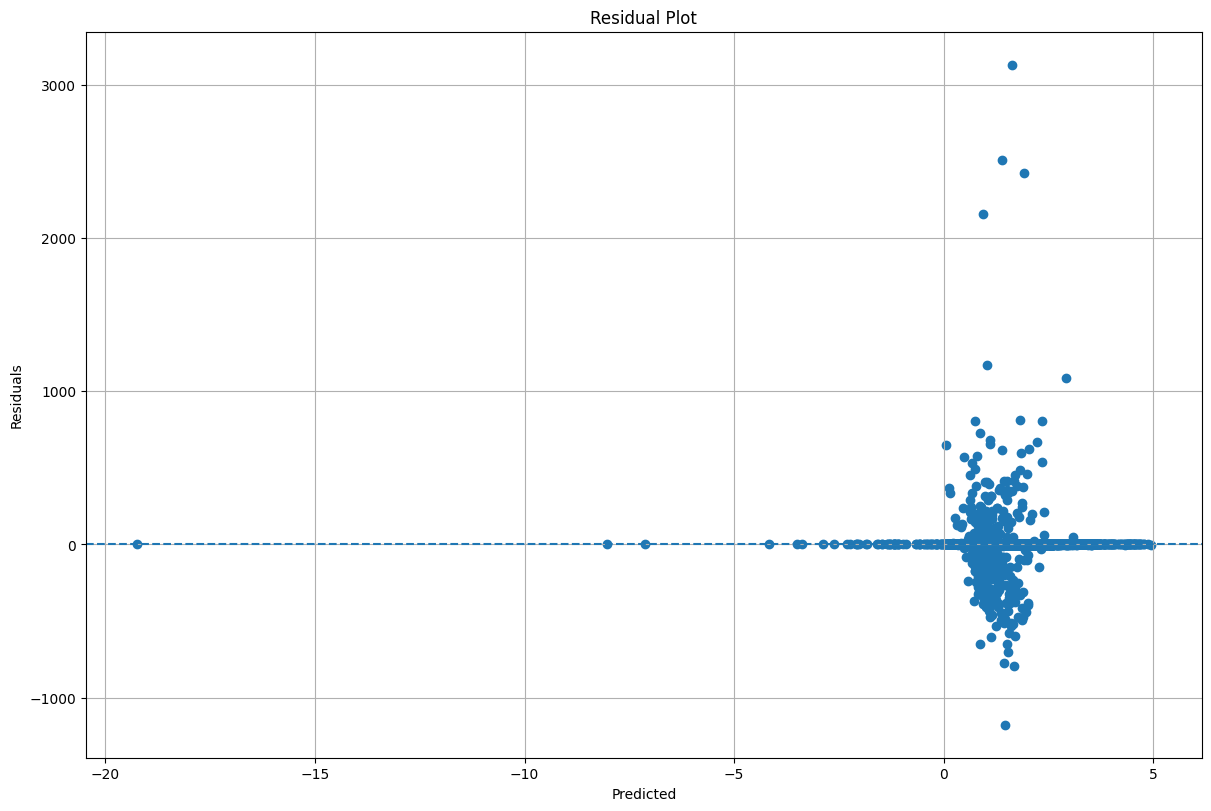

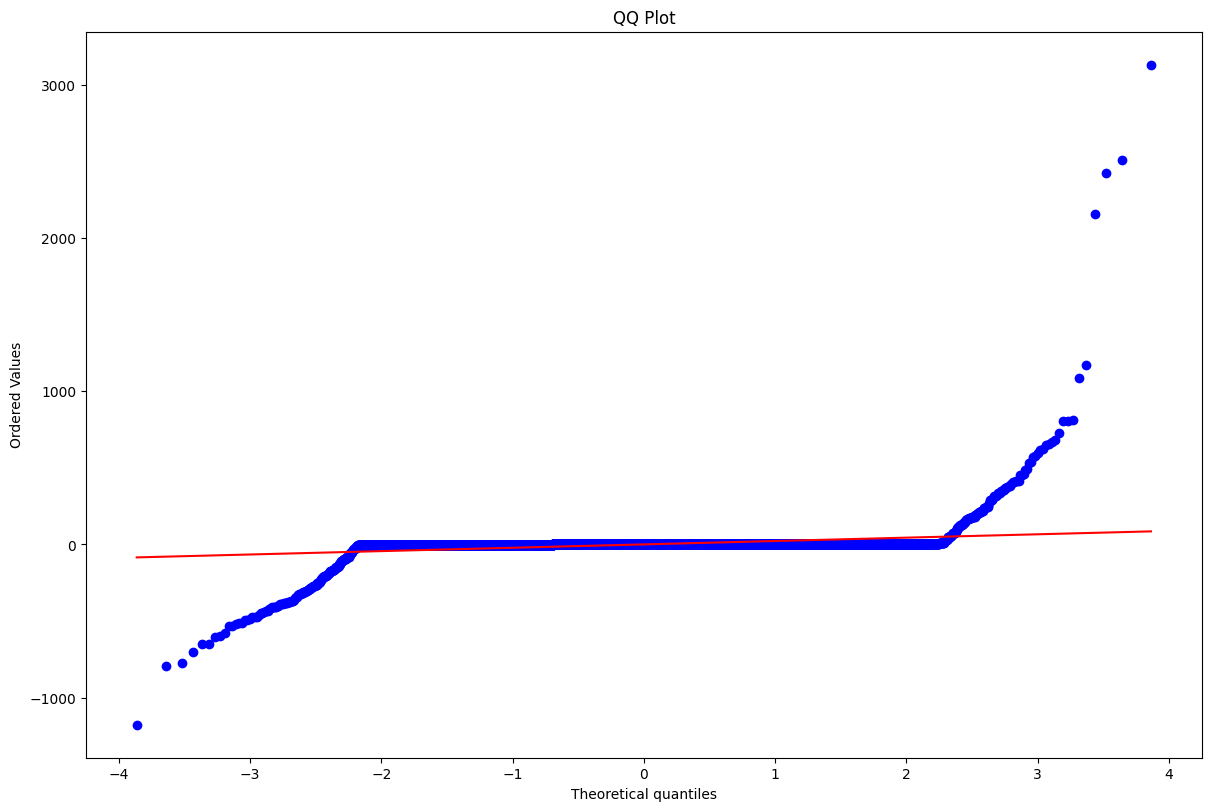

In [12]:
result = diag.breusch_pagan_test(d.X_train, residuals_train)
print(result)

if result["LM p-value"] < 0.05:
    aux = get_pipeline(OLS())
    aux.fit(d.X_train, np.square(residuals_train))

    sigma2_hat = aux.predict(d.X_train)
    sigma2_hat = np.clip(sigma2_hat, 1e-6, None)

    weights = 1.0 / sigma2_hat

    wls = get_pipeline(WLS(weights=weights))
    wls.fit(d.X_train, d.y_train)

    y_pred_train = wls.predict(d.X_train)
    residuals_train = d.y_train - y_pred_train
    weighted_residuals = np.sqrt(weights) * residuals_train

    diag.plot_residuals_direct(y_pred_train, weighted_residuals)
    plt.show()
    diag.plot_qq(weighted_residuals)
    plt.show()

#### Regularization and features selecton

#### Non-linear basis and Ablation study

##### Polynomial

### Advanced

#### Bayesian Regression


In [13]:
# ===== MODEL =====
X_train, y_train = d.X_train, d.y_train
X_test, y_test = d.X_test, d.y_test
model = BayesianLinearRegression(alpha=1.0, beta=10.0)
model.fit(X_train, y_train)


,alpha,1.0
,beta,10.0


In [14]:
 # ===== POSTERIOR =====
m_N, S_N = model.get_posterior()
print("Posterior mean shape:", m_N.shape)
print("Posterior covariance shape:", S_N.shape)

Posterior mean shape: (9, 1)
Posterior covariance shape: (9, 9)


In [15]:
 # ===== PREDICT =====
y_mean, y_std = model.predict_dist(X_test)
mse = np.mean((y_test - y_mean) ** 2)
print(f"MSE = {mse:.6f}")

MSE = 0.524602


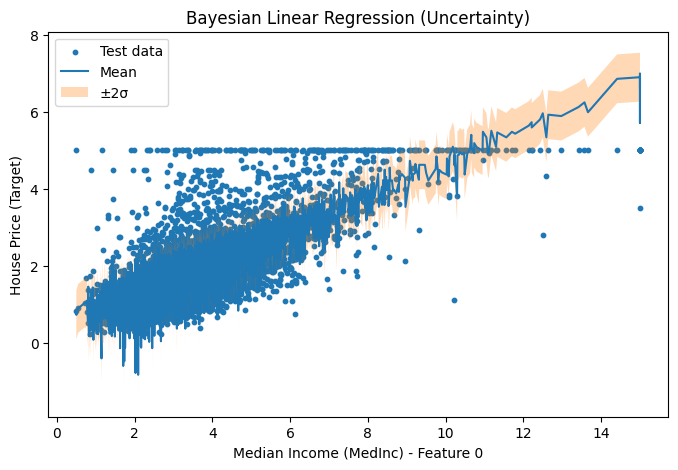

In [16]:
# ===== PLOT (1D visualization) =====
X_plot = X_test[:, 0]
idx = np.argsort(X_plot)

plt.figure(figsize=(8, 5))

# data test
plt.scatter(X_plot, y_test, s=10, label="Test data")

# mean prediction
plt.plot(X_plot[idx], y_mean[idx], label="Mean")

# vùng bất định ±2σ
plt.fill_between(
    X_plot[idx],
    y_mean[idx] - 2*y_std[idx],
    y_mean[idx] + 2*y_std[idx],
    alpha=0.3,
    label="±2σ"
)
plt.xlabel("Median Income (MedInc) - Feature 0")
plt.ylabel("House Price (Target)")
plt.legend()
plt.title("Bayesian Linear Regression (Uncertainty)")
plt.show()


In [17]:
#Optimazation alpha , beta using Evidence Maximization to compare with CV 
start = time.time()

model_em = BayesianLinearRegression()
model_em.evidence_maximization(X_train, y_train)

y_pred_em = model_em.predict(X_test)

em_time = time.time() - start
em_mse = mean_squared_error(y_test, y_pred_em)

#  CV 
param_grid = {
    "alpha": [0.1, 1, 10],
    "beta": [1, 10, 100]
}

start = time.time()

grid = GridSearchCV(
    BayesianLinearRegression(),
    param_grid,
    cv=3
)
grid.fit(X_train, y_train)

y_pred_cv = grid.predict(X_test)

cv_time = time.time() - start
cv_mse = mean_squared_error(y_test, y_pred_cv)

# ================= RESULT =================
print("\n===== EVIDENCE MAXIMIZATION =====")
print("alpha:", model_em.alpha)
print("beta:", model_em.beta)
print("MSE:", em_mse)
print("Time:", em_time)

print("\n===== CROSS VALIDATION =====")
print("Best params:", grid.best_params_)
print("MSE:", cv_mse)
print("Time:", cv_time)

print("\n===== COMPARISON =====")
print(f"EM faster than CV? {em_time < cv_time}")
print(f"EM better MSE than CV? {em_mse < cv_mse}")


===== EVIDENCE MAXIMIZATION =====
alpha: 0.0064293529731089686
beta: 1.9166775717920053
MSE: 0.5252559397214996
Time: 0.006520748138427734

===== CROSS VALIDATION =====
Best params: {'alpha': 0.1, 'beta': 100}
MSE: 0.5253081487282695
Time: 0.051505327224731445

===== COMPARISON =====
EM faster than CV? True
EM better MSE than CV? True


#### Gaussian Process Regression

In [18]:
rng = np.random.default_rng(42)
idx = rng.choice(len(d.X_train), 2000, replace=False)
X_sub = d.X_train[idx]
y_sub = d.y_train[idx]

model = get_pipeline(GPR())
model.fit(X_sub, y_sub)

y_pred, y_std = model.predict(d.X_test)
y_true = d.y_test
print("min std:", y_std.min())
print("max std:", y_std.max())

X_test = d.X_test

min std: 1.0
max std: 1.0


In [19]:
mean_squared_error(y_true, y_pred)

5.569207676845434

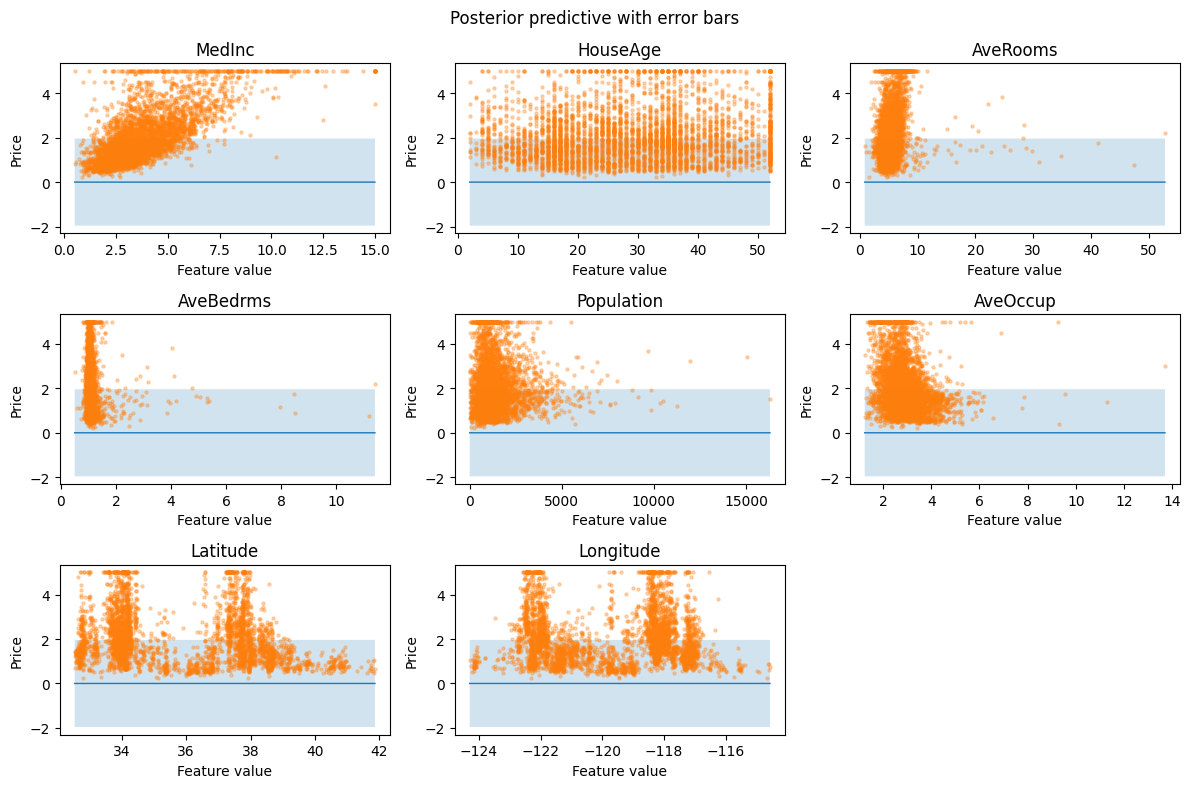

In [20]:
feature_names = getattr(d, "feature_names", [f"Feature {i}" for i in range(X_test.shape[1])])

n_features = X_test.shape[1]

for i in range(n_features):
    x_plot = X_test[:, i]
    idx = np.argsort(x_plot)

    plt.subplot(3, 3, i+1)

    # Prediction mean
    plt.plot(x_plot[idx], y_pred[idx], label="Pred", linewidth=1)

    # Uncertainty band
    plt.fill_between(
        x_plot[idx],
        y_pred[idx] - 1.96*y_std[idx],
        y_pred[idx] + 1.96*y_std[idx],
        # color="red",
        alpha=0.2
    )

    # True points
    plt.scatter(x_plot, y_true, s=5, alpha=0.3)

    plt.title(feature_names[i])
    plt.xlabel("Feature value")
    plt.ylabel("Price")
plt.gcf().suptitle("Posterior predictive with error bars")
plt.tight_layout()
plt.show()

#### Robust Regression

In [21]:
huber = get_pipeline(IRLS(loss="huber"))
huber.fit(d.X_train, d.y_train)
y_pred_huber = huber.predict(d.X_test)

student = get_pipeline(IRLS(loss="student-t"))
student.fit(d.X_train, d.y_train)
y_pred_student = student.predict(d.X_test)

model_ols = get_pipeline(OLS())
model_ols.fit(d.X_train, d.y_train)
y_pred_ols = model_ols.predict(d.X_test)

y_true = d.y_test

print("=== Overall MSE ===")
print(f"OLS: {mean_squared_error(y_true, y_pred_ols):.4f}")
print(f"Huber IRLS: {mean_squared_error(y_true, y_pred_huber):.4f}")
print(f"Student-t IRLS: {mean_squared_error(y_true, y_pred_student):.4f}")

=== Overall MSE ===
OLS: 0.5253
Huber IRLS: 0.5180
Student-t IRLS: 0.4726


In [22]:
# ===== TRAIN CLEAN =====
model_ols.fit(d.X_train, d.y_train)
huber.fit(d.X_train, d.y_train)
student.fit(d.X_train, d.y_train)

y_ols_clean = model_ols.predict(d.X_test)
y_huber_clean = huber.predict(d.X_test)
y_student_clean = student.predict(d.X_test)

# ===== ADD OUTLIER =====
y_train_noisy = d.y_train.copy()

idx = np.random.choice(len(d.y_train), int(0.1 * len(d.y_train)), replace=False)
y_train_noisy[idx] += 5 * np.std(d.y_train)

# ===== TRAIN NOISY =====
model_ols.fit(d.X_train, y_train_noisy)
huber.fit(d.X_train, y_train_noisy)
student.fit(d.X_train, y_train_noisy)

y_ols_noisy = model_ols.predict(d.X_test)
y_huber_noisy = huber.predict(d.X_test)
y_student_noisy = student.predict(d.X_test)

# ===== SENSITIVITY =====
print("\n=== Sensitivity ===")
print("OLS:", np.mean(np.abs(y_ols_clean - y_ols_noisy)))
print("Huber:", np.mean(np.abs(y_huber_clean - y_huber_noisy)))
print("Student:", np.mean(np.abs(y_student_clean - y_student_noisy)))


=== Sensitivity ===
OLS: 0.5758869457776407
Huber: 0.12241482834749891
Student: 0.08424075152555734


### Models evaluation

In [23]:
models = {
    "OLS": get_pipeline(OLS()),
    "IRLS (Huber)": get_pipeline(IRLS(loss="huber")),
    "IRLS (Student-t)": get_pipeline(IRLS(loss="student-t")),
    "Polynomial": get_pipeline(
        LinearRegression(),
        PolynomialBasis(degree=2) 
    ),
    "RBF": get_pipeline(LinearRegression(),
        RBF(n_centers=10, gamma=0.1)),
    "Fourier": get_pipeline(
        LinearRegression(),
        FourierBasis(n_terms=5) 
    )
}
evaluator = Evaluator()

result = evaluator.compare_models_cv(models, d.X_train, d.y_train)

print(result)

result = evaluator.compare_models_test(models, d.X_train, d.y_train,
                                       d.X_test, d.y_test)
print(result)

stat_result = evaluator.compare_models_statistical(
    models,
    d.X_train,
    d.y_train
)

print(stat_result)

              Model              MSE             RMSE              MAE  \
0               OLS  0.5345 ± 0.0384  0.7306 ± 0.0256  0.5315 ± 0.0068   
1      IRLS (Huber)  1.0015 ± 0.9877  0.9212 ± 0.3911  0.5233 ± 0.0158   
2  IRLS (Student-t)  3.8615 ± 6.2392  1.4698 ± 1.3043  0.5234 ± 0.0486   
3        Polynomial  0.6877 ± 0.5260  0.7943 ± 0.2383  0.5201 ± 0.0120   
4               RBF  0.7295 ± 0.0219  0.8540 ± 0.0128  0.6524 ± 0.0133   
5           Fourier  1.0607 ± 2.0013  0.8303 ± 0.6093  0.4597 ± 0.0270   

                 R2  
0   0.5961 ± 0.0237  
1   0.2227 ± 0.8028  
2  -2.0495 ± 5.0043  
3   0.4853 ± 0.3738  
4   0.4479 ± 0.0249  
5   0.2262 ± 1.4222  
              Model       MSE      RMSE       MAE        R2
0               OLS  0.525331  0.724797  0.529916  0.609737
1      IRLS (Huber)  0.518014  0.719732  0.512925  0.615173
2  IRLS (Student-t)  0.472567  0.687435  0.490149  0.648935
3        Polynomial  0.494023  0.702868  0.514549  0.632996
4               RBF  0.6971

### Model Complexity Analysis

#### MSE vs Polynomial Degree

[Polynomial] Param 1: MSE = 0.5253
[Polynomial] Param 2: MSE = 0.4940
[Polynomial] Param 3: MSE = 0.4563
[Polynomial] Param 4: MSE = 0.4427
[Polynomial] Param 5: MSE = 0.4151
[Polynomial] Param 6: MSE = 0.4042
[Polynomial] Param 7: MSE = 0.4020
[Polynomial] Param 8: MSE = 0.4013
[Polynomial] Param 9: MSE = 0.4241
[Polynomial] Param 10: MSE = 2.6425


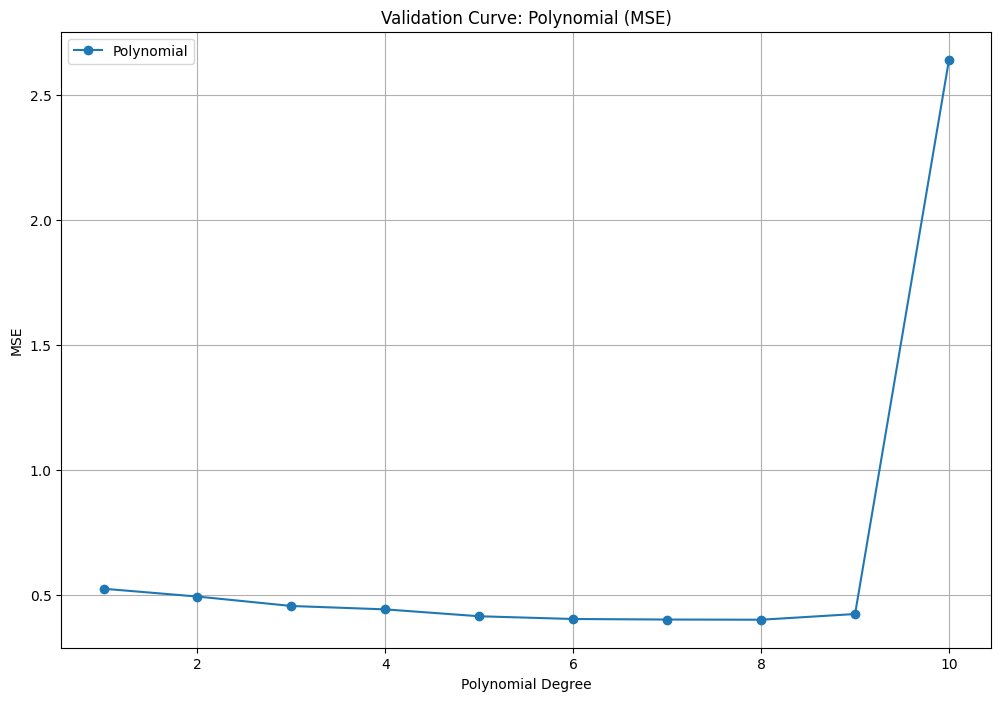

In [24]:
# Polynomial
poly_x, poly_y = run_validation_curve(
    X_train, y_train, X_test, y_test,
    param_list=list(range(1, 11)),
    transformer_fn=lambda d: PolynomialBasis(degree=d),
    evaluator=Evaluator,
    model_name="Polynomial"
)

Visualizer.plot_validation_curve(poly_x, poly_y, "Polynomial")

#### MSE vs Fourier

[Fourier] Param 1: MSE = 0.8370
[Fourier] Param 2: MSE = 0.6871
[Fourier] Param 3: MSE = 0.6451
[Fourier] Param 5: MSE = 0.6370
[Fourier] Param 7: MSE = 0.6248
[Fourier] Param 10: MSE = 0.6134
[Fourier] Param 20: MSE = 0.5605


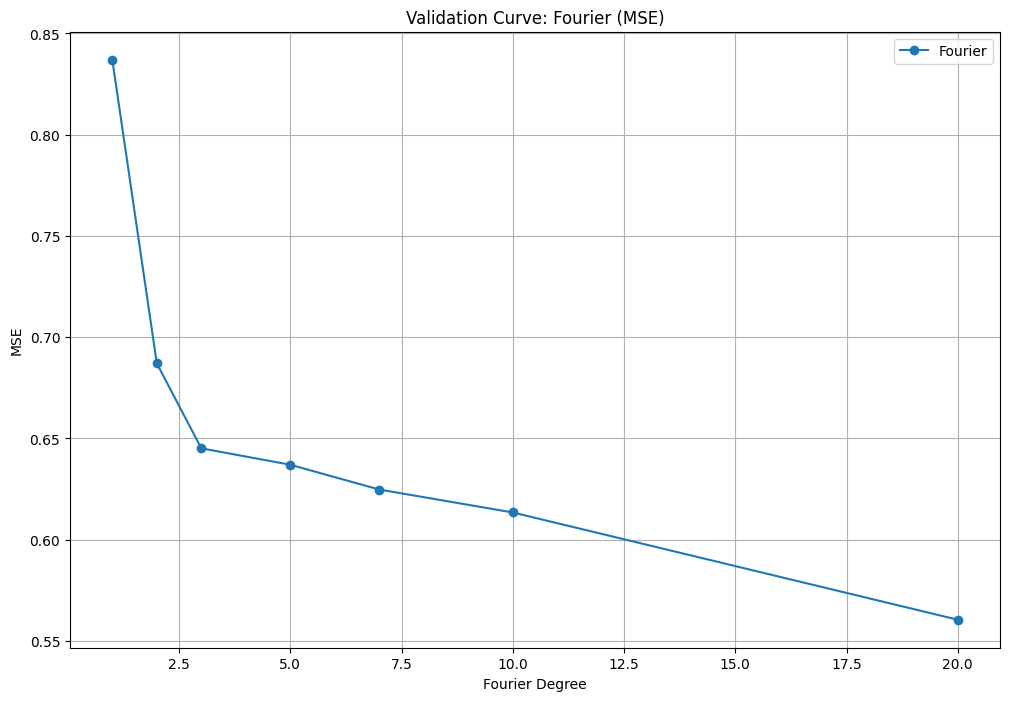

In [27]:
fourier_x, fourier_y = run_validation_curve(
    X_train, y_train, X_test, y_test,
    param_list=[1, 2, 3, 5, 7, 10,20],
    transformer_fn=lambda d: FourierBasis(d),
    evaluator=evaluator,
    model_name="Fourier"
)

Visualizer.plot_validation_curve(fourier_x, fourier_y, "Fourier")

#### Gaussian RBF + MSE


[Gaussian RBF] Param 5: MSE = 4514517606275177914648827227728248832.0000
[Gaussian RBF] Param 10: MSE = 84272280438808335885183885082298337583431699025976924116862097405808833707179510359443611058176.0000
[Gaussian RBF] Param 20: MSE = 1205127106103273524642499788800.0000
[Gaussian RBF] Param 30: MSE = 1605043030763222712607985351061272589451808111862617935107632600769164329489902713189465339122698642493494486877863936.0000
[Gaussian RBF] Param 50: MSE = 69705632478682112869085594196606560857598686278960794036276617775253634807434414897681847929572442909804531048744613913491493078619838591142009900293510370364932231777146512498418838851135448845393798138296715444224.0000


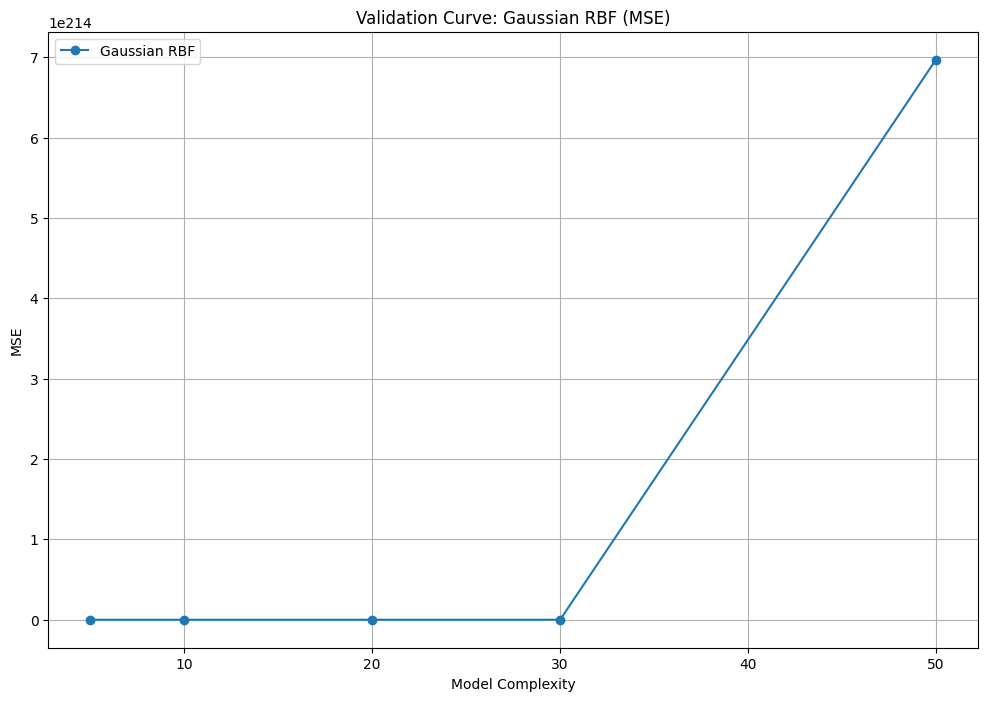

In [ ]:
evaluator = Evaluator()
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

rbf_x, rbf_y = run_validation_curve(
    X_train, y_train, X_test, y_test,
    param_list=[5, 10, 20, 30, 50],
    transformer_fn=lambda k: RBF(n_centers=k),
    evaluator=evaluator,
    model_name="Gaussian RBF"
)
Visualizer.plot_validation_curve(rbf_x, rbf_y, "Gaussian RBF")